# Kunqu Opera — Multimodal Synchrony Analysis

This notebook explores the aligned signals produced by the pipeline, analyzing
cross-modal rhythmic synchronization between **text** (lyrics), **audio** (singing/music),
and **motion** (body movement).

- **Part I** (Sections 1–7): Audio–motion synchrony (frame-level)
- **Part II** (Sections 8–13): Phrase-level & nonlinear audio–motion analysis
- **Part III** (Sections 14–20): Text modality — text–audio and text–motion synchrony

In [1]:
import numpy as np
import json
import matplotlib.pyplot as plt
from scipy.signal import correlate
from scipy.stats import pearsonr

VIDEO_ID = "xunmeng"

# Load aligned signals
data = np.load(f"../data/processed/{VIDEO_ID}_aligned_signals.npz")
with open(f"../data/processed/{VIDEO_ID}_aligned_signals.json") as f:
    meta = json.load(f)

# Load shot boundaries
with open(f"../data/processed/{VIDEO_ID}_shot_boundaries.json") as f:
    shot_data = json.load(f)

fps = meta["common_fps"]
times = data["times"]
cut_mask = data["cut_mask"].astype(bool)

# Check for text modality
has_text = "text_density" in data.files

print(f"Video: {VIDEO_ID}")
print(f"Duration: {meta['total_duration_sec']:.1f}s ({meta['total_frames']} frames @ {fps}fps)")
print(f"Cuts: {shot_data['num_cuts']}")
print(f"Motion NaN fraction: {meta['nan_fraction_motion']:.1%}")
if has_text:
    print(f"Text coverage: {meta.get('text_coverage_fraction', 0):.1%}")
    print(f"Characters: {meta['text']['num_characters']}, Breaths: {meta['text']['num_breaths']}")
print(f"\nAvailable signals: {sorted(data.files)}")

Video: xunmeng
Duration: 1494.3s (44829 frames @ 30fps)
Cuts: 19
Motion NaN fraction: 4.2%
Text coverage: 81.0%
Characters: 428, Breaths: 298

Available signals: ['audio_f0', 'audio_onset', 'audio_pitch_delta', 'audio_rms', 'cut_mask', 'motion_hand', 'motion_hand_left', 'motion_hand_right', 'motion_head', 'motion_root_displacement', 'motion_torso', 'motion_total', 'motion_upper_body', 'text_breath', 'text_char_duration', 'text_density', 'text_ioi', 'text_onset', 'text_silence_mask', 'times']


## 1. Signal Overview

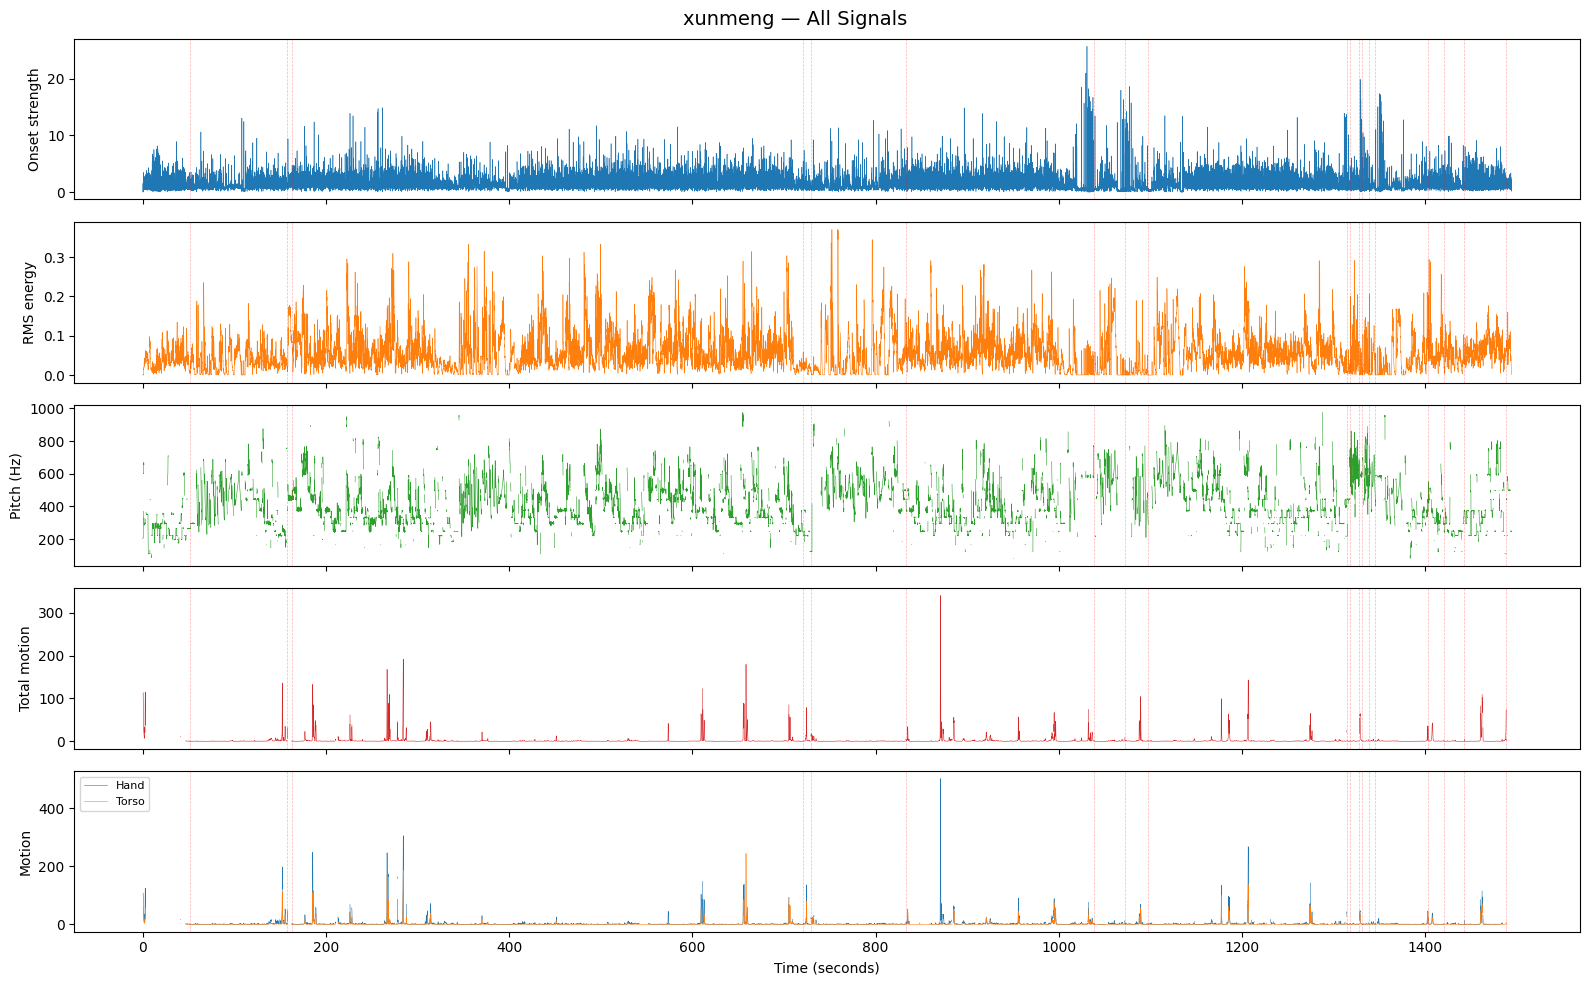

In [2]:
fig, axes = plt.subplots(5, 1, figsize=(16, 10), sharex=True)

axes[0].plot(times, data["audio_onset"], lw=0.4, color="C0")
axes[0].set_ylabel("Onset strength")

axes[1].plot(times, data["audio_rms"], lw=0.4, color="C1")
axes[1].set_ylabel("RMS energy")

axes[2].plot(times, data["audio_f0"], lw=0.4, color="C2")
axes[2].set_ylabel("Pitch (Hz)")

axes[3].plot(times, data["motion_total"], lw=0.4, color="C3")
axes[3].set_ylabel("Total motion")

axes[4].plot(times, data["motion_hand"], lw=0.4, color="C0", label="Hand")
axes[4].plot(times, data["motion_torso"], lw=0.4, color="C1", label="Torso")
axes[4].set_ylabel("Motion")
axes[4].legend(fontsize=8)

axes[-1].set_xlabel("Time (seconds)")

# Mark cuts
for ax in axes:
    for cf in shot_data["cuts"]:
        ax.axvline(cf / shot_data["video_fps"], color="red", ls="--", alpha=0.3, lw=0.5)

fig.suptitle(f"{VIDEO_ID} — All Signals", fontsize=14)
plt.tight_layout()
plt.show()

## 2. Per-Region Correlation with Audio Onset

Which body region tracks the music rhythm most closely?

In [3]:
onset = data["audio_onset"]

motion_signals = {
    "Total body": data["motion_total"],
    "Hand (combined)": data["motion_hand"],
    "Hand left": data["motion_hand_left"],
    "Hand right": data["motion_hand_right"],
    "Torso": data["motion_torso"],
    "Upper body": data["motion_upper_body"],
    "Head": data["motion_head"],
}

print(f"{'Region':<20s}  {'Pearson r':>10s}  {'p-value':>12s}  {'N valid':>10s}")
print("-" * 58)

results = []
for name, sig in motion_signals.items():
    valid = ~np.isnan(sig) & ~np.isnan(onset) & ~cut_mask
    n = valid.sum()
    if n > 100:
        r, p = pearsonr(onset[valid], sig[valid])
        results.append((name, r, p, n))
        print(f"{name:<20s}  {r:>10.4f}  {p:>12.2e}  {n:>10d}")
    else:
        print(f"{name:<20s}  {'(too few valid frames)':>34s}")

Region                 Pearson r       p-value     N valid
----------------------------------------------------------
Total body                0.0116      1.60e-02       42948
Hand (combined)           0.0119      1.95e-02       38621
Hand left                 0.0112      3.37e-02       35735
Hand right                0.0111      4.64e-02       32431
Torso                     0.0152      1.66e-03       42948
Upper body                0.0131      6.66e-03       42948
Head                      0.0124      1.00e-02       42948


## 3. Cross-Correlation (Lag Analysis)

Does motion lead or follow audio events? The peak lag reveals the temporal relationship.

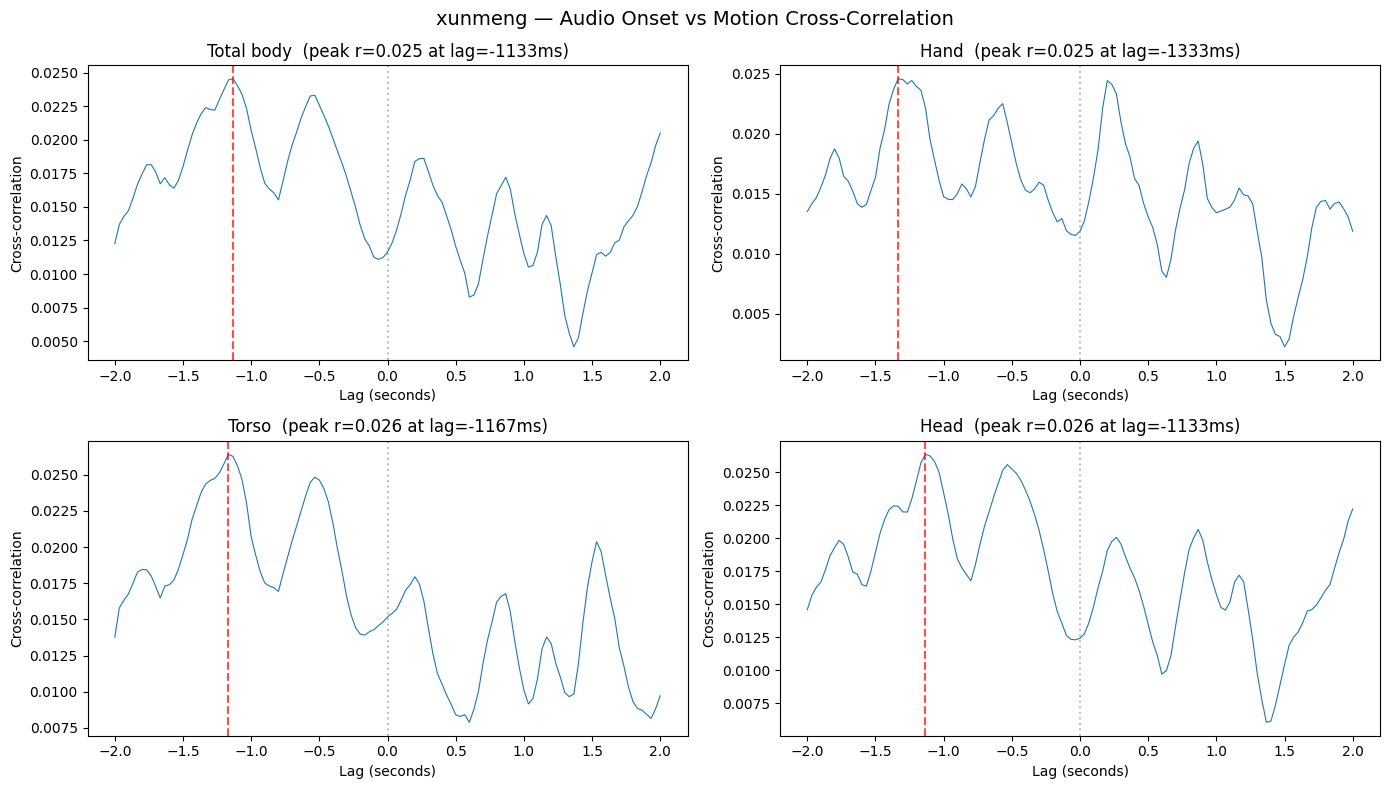

In [4]:
def compute_xcorr(sig_a, sig_b, valid_mask, max_lag_sec=2.0):
    """Compute normalized cross-correlation between two signals."""
    a = np.nan_to_num(sig_a[valid_mask])
    b = np.nan_to_num(sig_b[valid_mask])
    a = (a - a.mean()) / (a.std() + 1e-10)
    b = (b - b.mean()) / (b.std() + 1e-10)
    xcorr = correlate(a, b, mode="full") / len(a)
    lags = np.arange(-len(a) + 1, len(a)) / fps
    # Trim to max_lag
    mask = np.abs(lags) <= max_lag_sec
    return lags[mask], xcorr[mask]


valid = ~np.isnan(data["motion_total"]) & ~np.isnan(onset) & ~cut_mask

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (name, key) in zip(axes.flat, [
    ("Total body", "motion_total"),
    ("Hand", "motion_hand"),
    ("Torso", "motion_torso"),
    ("Head", "motion_head"),
]):
    v = ~np.isnan(data[key]) & ~np.isnan(onset) & ~cut_mask
    if v.sum() < 100:
        ax.set_title(f"{name} — insufficient data")
        continue
    lags, xcorr = compute_xcorr(onset, data[key], v)
    ax.plot(lags, xcorr, lw=0.8)
    peak_idx = np.argmax(xcorr)
    peak_lag = lags[peak_idx]
    peak_val = xcorr[peak_idx]
    ax.axvline(peak_lag, color="red", ls="--", alpha=0.7)
    ax.axvline(0, color="gray", ls=":", alpha=0.5)
    ax.set_title(f"{name}  (peak r={peak_val:.3f} at lag={peak_lag*1000:.0f}ms)")
    ax.set_xlabel("Lag (seconds)")
    ax.set_ylabel("Cross-correlation")

fig.suptitle(f"{VIDEO_ID} — Audio Onset vs Motion Cross-Correlation", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Windowed Correlation Over Time

How does the audio-motion coupling vary throughout the performance?
Sliding 10-second windows with 50% overlap.

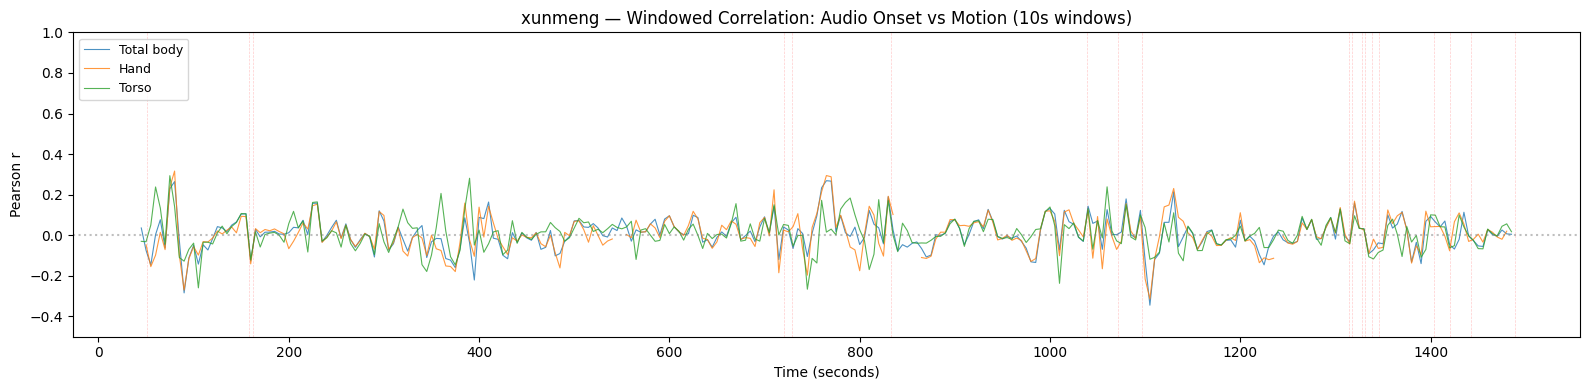

In [5]:
window_sec = 10
window = window_sec * fps
step = window // 2

windowed_corrs = {"time": [], "onset_vs_total": [], "onset_vs_hand": [], "onset_vs_torso": []}

for i in range(0, len(times) - window, step):
    s = slice(i, i + window)
    t_mid = times[i + window // 2]
    
    for label, motion_key in [
        ("onset_vs_total", "motion_total"),
        ("onset_vs_hand", "motion_hand"),
        ("onset_vs_torso", "motion_torso"),
    ]:
        v = ~np.isnan(onset[s]) & ~np.isnan(data[motion_key][s]) & ~cut_mask[s]
        if v.sum() > window * 0.3:
            r, _ = pearsonr(onset[s][v], data[motion_key][s][v])
        else:
            r = np.nan
        windowed_corrs[label].append(r)
    windowed_corrs["time"].append(t_mid)

fig, ax = plt.subplots(figsize=(16, 4))
t = windowed_corrs["time"]
ax.plot(t, windowed_corrs["onset_vs_total"], lw=0.8, label="Total body", alpha=0.8)
ax.plot(t, windowed_corrs["onset_vs_hand"], lw=0.8, label="Hand", alpha=0.8)
ax.plot(t, windowed_corrs["onset_vs_torso"], lw=0.8, label="Torso", alpha=0.8)
ax.axhline(0, color="gray", ls=":", alpha=0.5)
ax.set_ylabel("Pearson r")
ax.set_xlabel("Time (seconds)")
ax.set_title(f"{VIDEO_ID} — Windowed Correlation: Audio Onset vs Motion ({window_sec}s windows)")
ax.legend(fontsize=9)
ax.set_ylim(-0.5, 1.0)

for cf in shot_data["cuts"]:
    ax.axvline(cf / shot_data["video_fps"], color="red", ls="--", alpha=0.2, lw=0.5)

plt.tight_layout()
plt.show()

## 5. Pitch Contour vs Head Motion

In Kunqu, head movement may track melodic contour. Compare f0 (pitch) with head motion.

Pitch delta vs head motion: r=0.0011, p=8.57e-01, N=24882


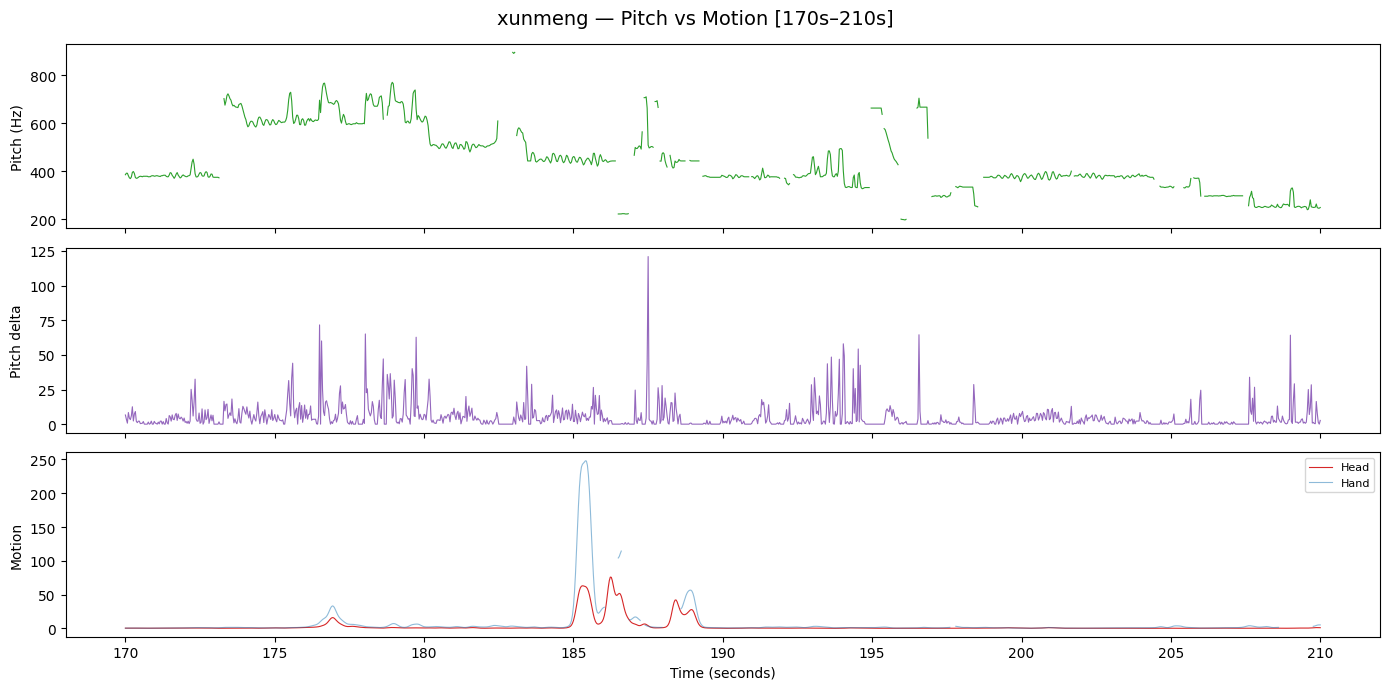

In [6]:
f0 = data["audio_f0"]
head = data["motion_head"]
pdelta = data["audio_pitch_delta"]

# Pitch delta vs head motion — does head move more during melodic jumps?
v = ~np.isnan(pdelta) & ~np.isnan(head) & ~cut_mask & (pdelta > 0)
if v.sum() > 100:
    r, p = pearsonr(pdelta[v], head[v])
    print(f"Pitch delta vs head motion: r={r:.4f}, p={p:.2e}, N={v.sum()}")

# Visualize a segment
seg_start, seg_end = 170, 210  # seconds — adjust as needed
mask = (times >= seg_start) & (times <= seg_end)

fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)

axes[0].plot(times[mask], f0[mask], lw=0.8, color="C2")
axes[0].set_ylabel("Pitch (Hz)")

axes[1].plot(times[mask], pdelta[mask], lw=0.8, color="C4")
axes[1].set_ylabel("Pitch delta")

axes[2].plot(times[mask], head[mask], lw=0.8, color="C3", label="Head")
axes[2].plot(times[mask], data["motion_hand"][mask], lw=0.8, color="C0", alpha=0.5, label="Hand")
axes[2].set_ylabel("Motion")
axes[2].legend(fontsize=8)

axes[-1].set_xlabel("Time (seconds)")
fig.suptitle(f"{VIDEO_ID} — Pitch vs Motion [{seg_start}s–{seg_end}s]", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Per-Segment Analysis

Analyze each continuous shot independently to avoid cross-cut artifacts.

In [7]:
video_fps = shot_data["video_fps"]

print(f"{'Segment':<10s}  {'Start':>7s}  {'End':>7s}  {'Dur(s)':>7s}  {'r(onset,total)':>15s}  {'r(onset,hand)':>15s}")
print("-" * 72)

seg_results = []
for i, seg in enumerate(shot_data["segments"]):
    # Convert from video frames to common timeline frames
    t_start = seg["start_frame"] / video_fps
    t_end = seg["end_frame"] / video_fps
    s = (times >= t_start) & (times <= t_end)
    
    dur = seg["duration_sec"]
    
    row = {"seg": i, "start": t_start, "end": t_end, "dur": dur}
    
    for label, motion_key in [("r_total", "motion_total"), ("r_hand", "motion_hand")]:
        v = s & ~np.isnan(onset) & ~np.isnan(data[motion_key]) & ~cut_mask
        if v.sum() > 30:
            r, _ = pearsonr(onset[v], data[motion_key][v])
            row[label] = r
        else:
            row[label] = np.nan
    
    seg_results.append(row)
    r_t = f"{row.get('r_total', np.nan):.3f}" if not np.isnan(row.get('r_total', np.nan)) else "n/a"
    r_h = f"{row.get('r_hand', np.nan):.3f}" if not np.isnan(row.get('r_hand', np.nan)) else "n/a"
    print(f"  {i:<8d}  {t_start:>6.1f}s  {t_end:>6.1f}s  {dur:>6.1f}s  {r_t:>15s}  {r_h:>15s}")

Segment       Start      End   Dur(s)   r(onset,total)    r(onset,hand)
------------------------------------------------------------------------
  0            0.0s    51.4s    51.5s           -0.077           -0.041
  1           51.5s   157.7s   106.3s            0.030            0.030
  2          157.8s   162.5s     4.8s              n/a              n/a
  3          162.5s   720.8s   558.3s            0.017            0.015
  4          720.8s   729.1s     8.3s            0.050            0.033
  5          729.1s   832.8s   103.7s           -0.019            0.001
  6          832.8s  1038.4s   205.6s           -0.004           -0.002
  7         1038.4s  1071.8s    33.4s           -0.000           -0.001
  8         1071.8s  1097.0s    25.2s            0.005            0.011
  9         1097.0s  1314.0s   217.1s            0.008            0.013
  10        1314.1s  1317.5s     3.5s           -0.028           -0.027
  11        1317.5s  1328.1s    10.6s            0.106         

## 7. Data Quality Summary

Overview of NaN coverage and signal statistics.

In [8]:
print("Signal NaN fractions:")
print(f"  {'Signal':<25s}  {'NaN %':>8s}  {'Mean':>10s}  {'Std':>10s}")
print("  " + "-" * 58)
for key in sorted(data.files):
    if key in ("times", "cut_mask"):
        continue
    arr = data[key]
    nan_pct = np.isnan(arr).mean() * 100
    valid_vals = arr[~np.isnan(arr)]
    mean = np.mean(valid_vals) if len(valid_vals) > 0 else 0
    std = np.std(valid_vals) if len(valid_vals) > 0 else 0
    print(f"  {key:<25s}  {nan_pct:>7.1f}%  {mean:>10.3f}  {std:>10.3f}")

print(f"\nCut mask coverage: {cut_mask.mean()*100:.1f}% of frames")
print(f"Motion metadata: root_mode={meta['motion']['root_mode_resolved']}, "
      f"scale_cv={meta['motion']['scale_reference_cv']}")

Signal NaN fractions:
  Signal                        NaN %        Mean         Std
  ----------------------------------------------------------
  audio_f0                      18.9%     406.655     139.770
  audio_onset                    0.0%       1.455       1.184
  audio_pitch_delta              0.0%       3.455       7.766
  audio_rms                      0.0%       0.055       0.048
  motion_hand                   13.8%       3.530      13.953
  motion_hand_left              20.3%       3.549      14.449
  motion_hand_right             27.7%       3.155      12.526
  motion_head                    4.2%       1.387       7.088
  motion_root_displacement       3.9%      88.225     270.771
  motion_torso                   4.2%       1.415       7.435
  motion_total                   4.2%       2.164       9.476
  motion_upper_body              4.2%       1.462       6.874
  text_breath                    0.0%       0.007       0.019
  text_char_duration             0.0%       4.290

---

# Part II — Phrase-Level & Nonlinear Analysis

Frame-level Pearson correlations (Part I) are near zero because Kunqu movement is
**phrased and gestural**, not beat-synchronous. The sections below use methods better
suited to this art form: envelope smoothing, event-triggered averaging, multi-scale
analysis, and mutual information.

## 8. Multi-Scale Envelope Correlation

Smooth both audio and motion with increasing window sizes (0.5s → 30s) and measure
correlation at each scale. If coupling exists at the phrase level but not the beat
level, correlation should increase with smoothing window.

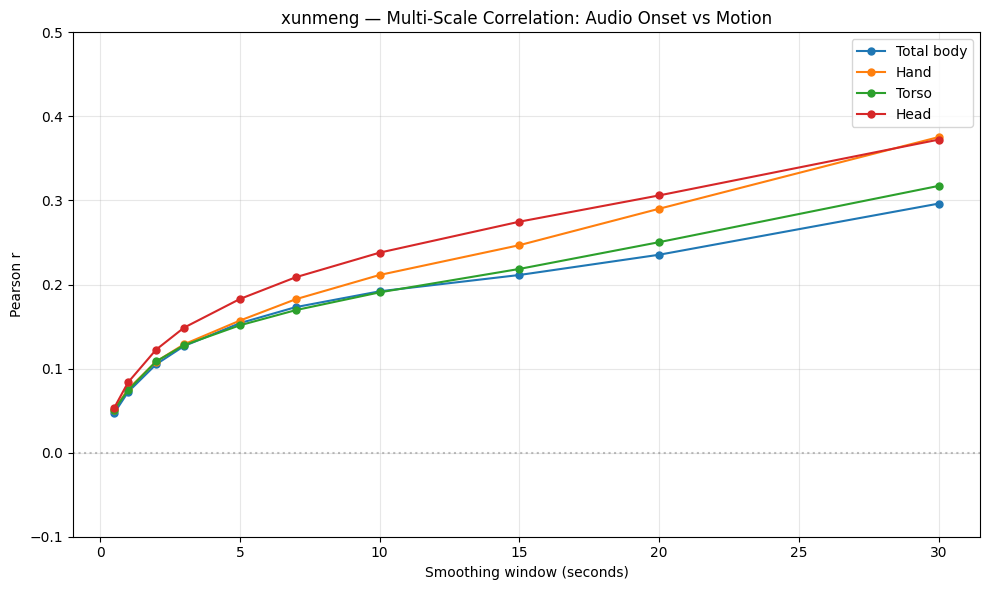


Correlation at each scale (Total body):
    0.5s  r = 0.0532
    1.0s  r = 0.0837
    2.0s  r = 0.1225
    3.0s  r = 0.1487
    5.0s  r = 0.1828
    7.0s  r = 0.2087
   10.0s  r = 0.2379
   15.0s  r = 0.2748
   20.0s  r = 0.3060
   30.0s  r = 0.3724


In [9]:
from scipy.ndimage import uniform_filter1d

window_sizes = [0.5, 1, 2, 3, 5, 7, 10, 15, 20, 30]  # seconds

motion_keys = {
    "Total body": "motion_total",
    "Hand": "motion_hand",
    "Torso": "motion_torso",
    "Head": "motion_head",
}

fig, ax = plt.subplots(figsize=(10, 6))

for label, key in motion_keys.items():
    corrs = []
    for ws in window_sizes:
        wf = int(ws * fps)
        if wf < 2:
            wf = 2
        # Smooth both signals
        a = onset.copy()
        m = data[key].copy()
        v = ~np.isnan(m) & ~np.isnan(a) & ~cut_mask
        a_smooth = np.full_like(a, np.nan)
        m_smooth = np.full_like(m, np.nan)
        a_smooth[v] = uniform_filter1d(a[v], size=wf)
        m_smooth[v] = uniform_filter1d(m[v], size=wf)
        v2 = ~np.isnan(a_smooth) & ~np.isnan(m_smooth)
        if v2.sum() > 100:
            r, _ = pearsonr(a_smooth[v2], m_smooth[v2])
        else:
            r = np.nan
        corrs.append(r)
    ax.plot(window_sizes, corrs, 'o-', label=label, markersize=5)

ax.set_xlabel("Smoothing window (seconds)")
ax.set_ylabel("Pearson r")
ax.set_title(f"{VIDEO_ID} — Multi-Scale Correlation: Audio Onset vs Motion")
ax.legend()
ax.axhline(0, color="gray", ls=":", alpha=0.5)
ax.set_ylim(-0.1, max(0.5, ax.get_ylim()[1]))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nCorrelation at each scale (Total body):")
for ws, r in zip(window_sizes, corrs):
    print(f"  {ws:5.1f}s  r = {r:.4f}")

## 9. RMS Energy Envelope vs Motion Envelope

Instead of onset (transient attacks), use RMS energy — a smoother measure of musical
intensity. Smooth both to 5s envelopes and compare. This tests: "are loud/active
musical passages also physically active passages?"

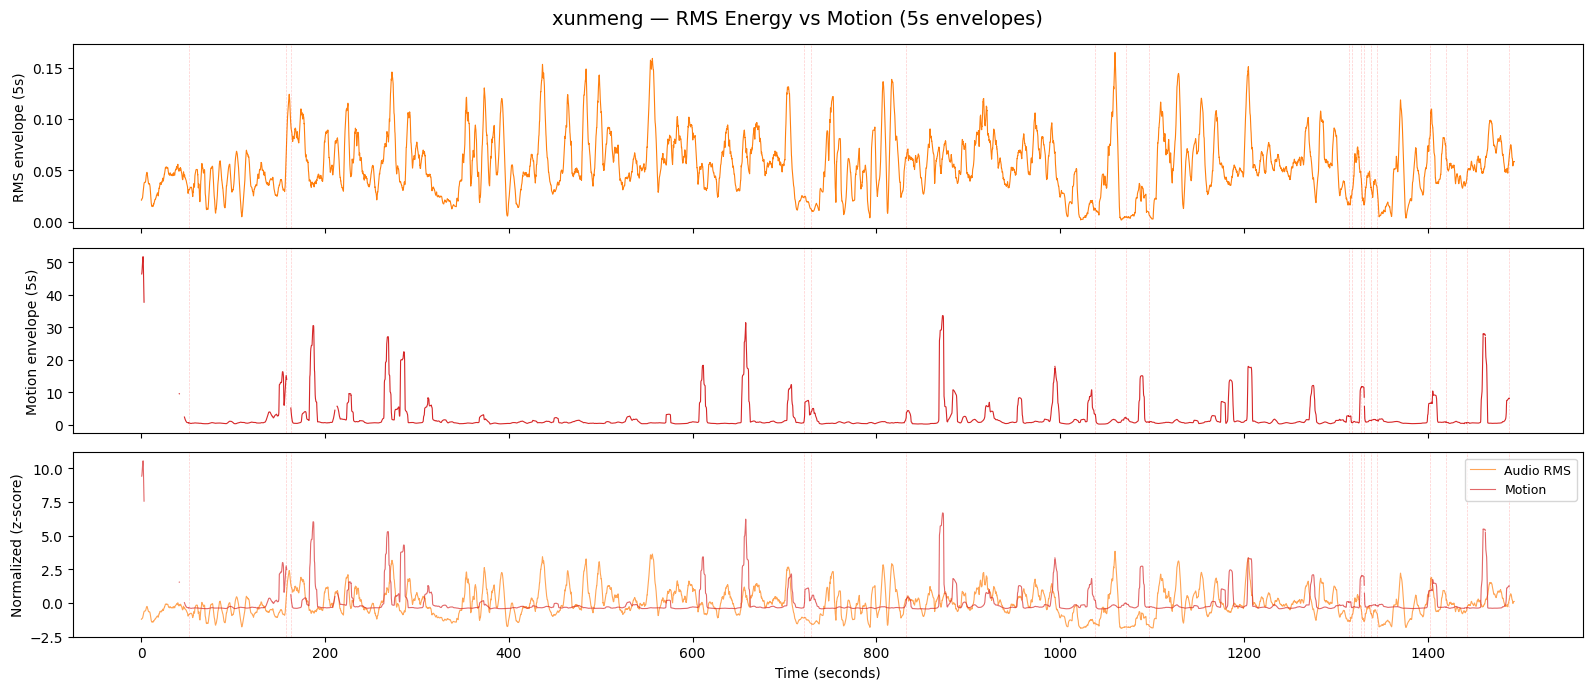

RMS envelope vs motion envelope (5s): r=-0.0062, p=2.01e-01, N=42948


In [10]:
rms = data["audio_rms"]
env_window = int(5 * fps)  # 5-second envelope

fig, axes = plt.subplots(3, 1, figsize=(16, 7), sharex=True)

# Smooth RMS
rms_env = uniform_filter1d(rms, size=env_window)

# Smooth motion (handle NaN)
mt = data["motion_total"].copy()
v = ~np.isnan(mt)
mt_filled = np.interp(np.arange(len(mt)), np.where(v)[0], mt[v]) if v.any() else mt
mt_env = uniform_filter1d(mt_filled, size=env_window)
mt_env[~v] = np.nan  # restore NaN

axes[0].plot(times, rms_env, lw=0.8, color="C1")
axes[0].set_ylabel("RMS envelope (5s)")

axes[1].plot(times, mt_env, lw=0.8, color="C3")
axes[1].set_ylabel("Motion envelope (5s)")

# Overlay normalized versions
v2 = ~np.isnan(mt_env)
rms_n = (rms_env - rms_env[v2].mean()) / rms_env[v2].std()
mt_n = np.full_like(mt_env, np.nan)
mt_n[v2] = (mt_env[v2] - mt_env[v2].mean()) / mt_env[v2].std()

axes[2].plot(times, rms_n, lw=0.8, color="C1", alpha=0.7, label="Audio RMS")
axes[2].plot(times, mt_n, lw=0.8, color="C3", alpha=0.7, label="Motion")
axes[2].set_ylabel("Normalized (z-score)")
axes[2].legend(fontsize=9)

for ax in axes:
    for cf in shot_data["cuts"]:
        ax.axvline(cf / shot_data["video_fps"], color="red", ls="--", alpha=0.2, lw=0.5)

axes[-1].set_xlabel("Time (seconds)")
fig.suptitle(f"{VIDEO_ID} — RMS Energy vs Motion (5s envelopes)", fontsize=14)
plt.tight_layout()
plt.show()

# Correlation
v3 = ~np.isnan(mt_env) & ~cut_mask
r, p = pearsonr(rms_env[v3], mt_env[v3])
print(f"RMS envelope vs motion envelope (5s): r={r:.4f}, p={p:.2e}, N={v3.sum()}")

## 10. Event-Triggered Averaging

Find strong audio onset peaks, then average the motion signal in a window around each
peak. Even if frame-level correlation is low, a consistent motion response (e.g., a
bump ~0.5s after an onset) would appear in the average.

Found 2576 onset peaks, 2343 with clean motion data


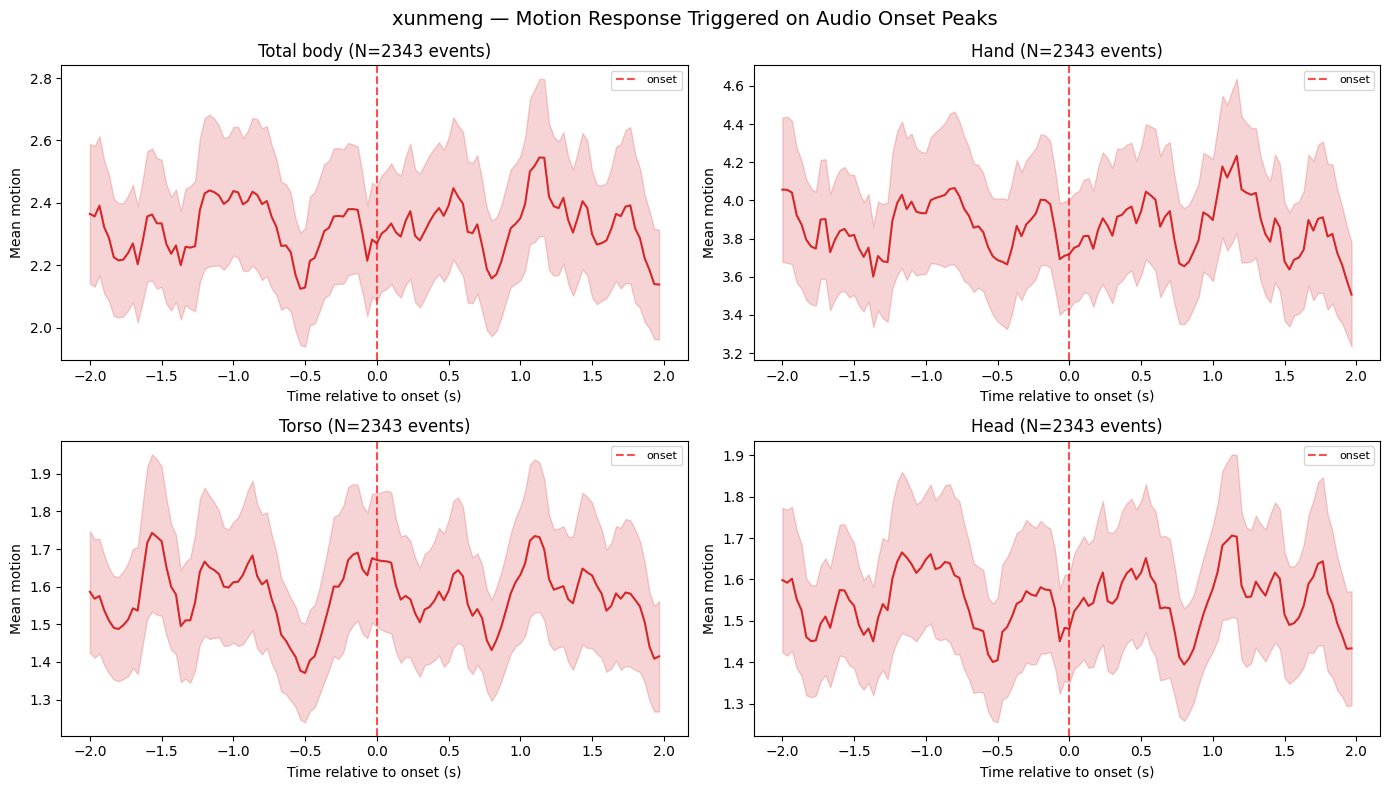

In [11]:
from scipy.signal import find_peaks

# Find prominent onset peaks (top 15% by height)
peak_threshold = np.nanpercentile(onset, 85)
peaks, props = find_peaks(onset, height=peak_threshold, distance=int(0.3 * fps))

# Filter out peaks near NaN motion or cuts
window_frames = int(2 * fps)  # +/- 2 seconds
valid_peaks = []
for p in peaks:
    if p < window_frames or p >= len(times) - window_frames:
        continue
    seg = slice(p - window_frames, p + window_frames)
    if cut_mask[seg].any():
        continue
    if np.isnan(data["motion_total"][seg]).mean() < 0.2:
        valid_peaks.append(p)

print(f"Found {len(peaks)} onset peaks, {len(valid_peaks)} with clean motion data")

# Event-triggered average
lag_times = np.arange(-window_frames, window_frames) / fps  # seconds

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (label, key) in zip(axes.flat, [
    ("Total body", "motion_total"),
    ("Hand", "motion_hand"),
    ("Torso", "motion_torso"),
    ("Head", "motion_head"),
]):
    snippets = []
    for p in valid_peaks:
        seg = data[key][p - window_frames:p + window_frames]
        if len(seg) == len(lag_times):
            snippets.append(seg)
    
    if len(snippets) < 10:
        ax.set_title(f"{label} — too few events")
        continue
    
    snippets = np.array(snippets)
    mean_response = np.nanmean(snippets, axis=0)
    sem = np.nanstd(snippets, axis=0) / np.sqrt(np.sum(~np.isnan(snippets), axis=0).clip(1))
    
    ax.plot(lag_times, mean_response, lw=1.5, color="C3")
    ax.fill_between(lag_times, mean_response - sem, mean_response + sem, alpha=0.2, color="C3")
    ax.axvline(0, color="red", ls="--", alpha=0.7, label="onset")
    ax.set_xlabel("Time relative to onset (s)")
    ax.set_ylabel("Mean motion")
    ax.set_title(f"{label} (N={len(snippets)} events)")
    ax.legend(fontsize=8)

fig.suptitle(f"{VIDEO_ID} — Motion Response Triggered on Audio Onset Peaks", fontsize=14)
plt.tight_layout()
plt.show()

## 11. Onset-Triggered Average of Audio (sanity check)

Same technique applied to audio onset itself — should show a sharp peak at lag=0,
confirming the method works.

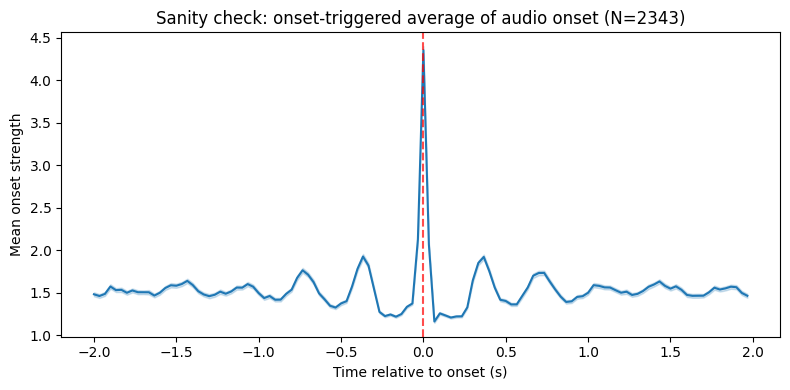

In [12]:
# Sanity check: onset-triggered average of onset itself
onset_snippets = []
for p in valid_peaks:
    seg = onset[p - window_frames:p + window_frames]
    if len(seg) == len(lag_times):
        onset_snippets.append(seg)

onset_snippets = np.array(onset_snippets)
onset_mean = np.nanmean(onset_snippets, axis=0)
onset_sem = np.nanstd(onset_snippets, axis=0) / np.sqrt(len(onset_snippets))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lag_times, onset_mean, lw=1.5, color="C0")
ax.fill_between(lag_times, onset_mean - onset_sem, onset_mean + onset_sem, alpha=0.2, color="C0")
ax.axvline(0, color="red", ls="--", alpha=0.7)
ax.set_xlabel("Time relative to onset (s)")
ax.set_ylabel("Mean onset strength")
ax.set_title(f"Sanity check: onset-triggered average of audio onset (N={len(onset_snippets)})")
plt.tight_layout()
plt.show()

## 12. Mutual Information

Pearson r only captures linear relationships. Mutual information (MI) captures any
statistical dependency, including nonlinear ones. We compare MI of the real signals
against MI of time-shuffled surrogates to test significance.

In [13]:
from sklearn.metrics import mutual_info_score

def discretize(signal, n_bins=20):
    """Discretize a continuous signal into bins for MI estimation."""
    valid = signal[~np.isnan(signal)]
    if len(valid) == 0:
        return np.full_like(signal, 0, dtype=int)
    edges = np.linspace(np.percentile(valid, 1), np.percentile(valid, 99), n_bins + 1)
    return np.clip(np.digitize(signal, edges) - 1, 0, n_bins - 1)

def compute_mi_with_surrogates(sig_a, sig_b, mask, n_surrogates=200, n_bins=20):
    """Compute MI and compare against shuffled surrogates."""
    a = sig_a[mask]
    b = sig_b[mask]
    a_d = discretize(a, n_bins)
    b_d = discretize(b, n_bins)
    mi_real = mutual_info_score(a_d, b_d)
    
    mi_surr = []
    rng = np.random.default_rng(42)
    for _ in range(n_surrogates):
        b_shuf = rng.permutation(b_d)
        mi_surr.append(mutual_info_score(a_d, b_shuf))
    mi_surr = np.array(mi_surr)
    
    z_score = (mi_real - mi_surr.mean()) / (mi_surr.std() + 1e-10)
    p_value = (mi_surr >= mi_real).mean()
    return mi_real, mi_surr.mean(), z_score, p_value

print(f"{'Signal pair':<35s}  {'MI':>8s}  {'Surr.mean':>10s}  {'z-score':>8s}  {'p':>8s}")
print("-" * 75)

pairs = [
    ("Onset vs Total body", onset, data["motion_total"]),
    ("Onset vs Hand", onset, data["motion_hand"]),
    ("Onset vs Torso", onset, data["motion_torso"]),
    ("Onset vs Head", onset, data["motion_head"]),
    ("RMS vs Total body", rms, data["motion_total"]),
    ("Pitch delta vs Head", data["audio_pitch_delta"], data["motion_head"]),
]

for label, sa, sb in pairs:
    v = ~np.isnan(sa) & ~np.isnan(sb) & ~cut_mask
    if v.sum() < 200:
        print(f"{label:<35s}  insufficient data")
        continue
    mi, surr_mean, z, p = compute_mi_with_surrogates(sa, sb, v)
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    print(f"{label:<35s}  {mi:>8.4f}  {surr_mean:>10.4f}  {z:>8.2f}  {p:>7.3f} {sig}")

Signal pair                                MI   Surr.mean   z-score         p
---------------------------------------------------------------------------


Onset vs Total body                    0.0045      0.0041      1.47    0.060 


Onset vs Hand                          0.0045      0.0046     -0.38    0.595 


Onset vs Torso                         0.0048      0.0041      2.38    0.005 **


Onset vs Head                          0.0047      0.0042      2.02    0.025 *


RMS vs Total body                      0.0088      0.0044     15.18    0.000 ***


Pitch delta vs Head                    0.0044      0.0037      2.42    0.005 **


## 13. Phrase-Level Activity Segmentation

Classify each 10-second window as "active" or "quiet" for both audio (by RMS) and
motion (by total motion). Then check agreement: do active audio windows coincide
with active motion windows?

Windows analyzed: 144
Agreement (active/quiet match): 48.6%
Cohen's kappa: -0.028
  (0 = chance, 0.2 = slight, 0.4 = fair, 0.6 = moderate, 0.8 = substantial)

Confusion matrix:
                  Motion quiet  Motion active
  Audio quiet               35             37
  Audio active              37             35


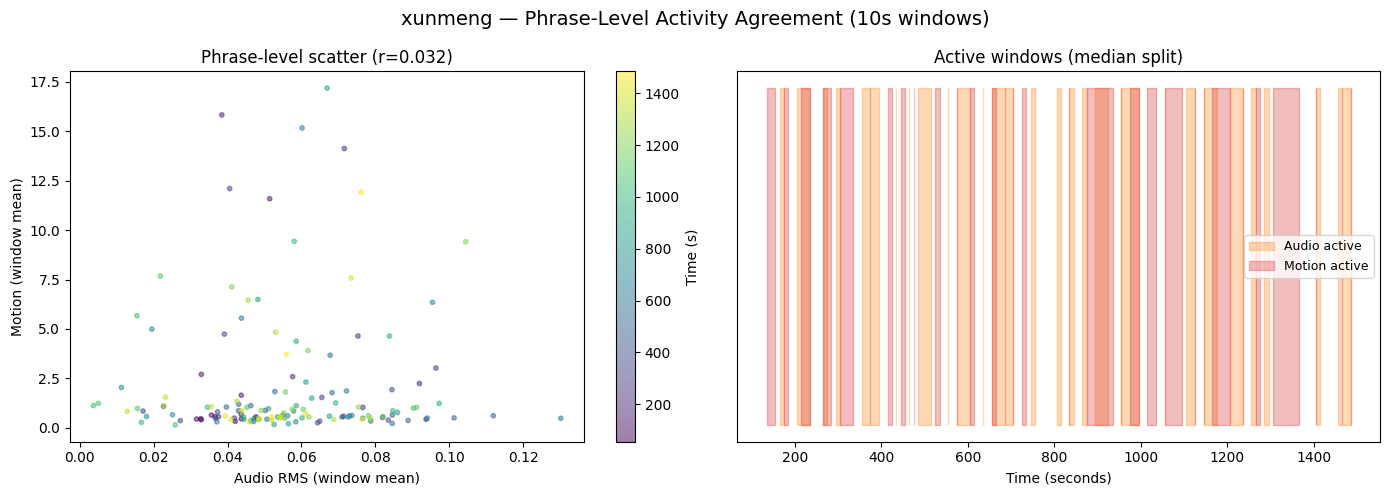

In [14]:
from sklearn.metrics import confusion_matrix, cohen_kappa_score

window_sec = 10
window = int(window_sec * fps)

audio_activity = []
motion_activity = []
window_times = []

for i in range(0, len(times) - window, window):
    s = slice(i, i + window)
    if cut_mask[s].mean() > 0.3:
        continue
    mt = data["motion_total"][s]
    if np.isnan(mt).mean() > 0.5:
        continue
    
    audio_activity.append(np.mean(rms[s]))
    motion_activity.append(np.nanmean(mt))
    window_times.append(times[i + window // 2])

audio_activity = np.array(audio_activity)
motion_activity = np.array(motion_activity)
window_times = np.array(window_times)

# Binarize by median split
audio_active = audio_activity > np.median(audio_activity)
motion_active = motion_activity > np.median(motion_activity)

# Agreement
agreement = (audio_active == motion_active).mean()
kappa = cohen_kappa_score(audio_active, motion_active)
cm = confusion_matrix(audio_active, motion_active)

print(f"Windows analyzed: {len(audio_activity)}")
print(f"Agreement (active/quiet match): {agreement:.1%}")
print(f"Cohen's kappa: {kappa:.3f}")
print(f"  (0 = chance, 0.2 = slight, 0.4 = fair, 0.6 = moderate, 0.8 = substantial)")
print(f"\nConfusion matrix:")
print(f"                  Motion quiet  Motion active")
print(f"  Audio quiet     {cm[0,0]:>12d}  {cm[0,1]:>13d}")
print(f"  Audio active    {cm[1,0]:>12d}  {cm[1,1]:>13d}")

# Scatter plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(audio_activity, motion_activity, s=10, alpha=0.5, c=window_times, cmap="viridis")
axes[0].set_xlabel("Audio RMS (window mean)")
axes[0].set_ylabel("Motion (window mean)")
axes[0].set_title(f"Phrase-level scatter (r={np.corrcoef(audio_activity, motion_activity)[0,1]:.3f})")
cb = plt.colorbar(axes[0].collections[0], ax=axes[0])
cb.set_label("Time (s)")

# Activity timeline
axes[1].fill_between(window_times, 0, 1, where=audio_active, alpha=0.3, color="C1", label="Audio active", step="mid")
axes[1].fill_between(window_times, 0, 1, where=motion_active, alpha=0.3, color="C3", label="Motion active", step="mid")
axes[1].set_xlabel("Time (seconds)")
axes[1].set_yticks([])
axes[1].set_title("Active windows (median split)")
axes[1].legend(fontsize=9)

fig.suptitle(f"{VIDEO_ID} — Phrase-Level Activity Agreement ({window_sec}s windows)", fontsize=14)
plt.tight_layout()
plt.show()

---

# Part III — Text Modality: Lyrics–Audio–Motion Synchrony

With character-level text annotations aligned to the same timeline, we can now ask:
- Does motion intensity track **singing density** (chars/sec)?
- Do performers move in response to **character onsets** (syllable attacks)?
- How does the **text–audio** relationship compare to **text–motion**?
- Are **breath marks** (phrase boundaries) associated with motion pauses or transitions?

## 14. Text Signal Overview

Visualize all text rhythm signals alongside audio and motion for a representative segment.

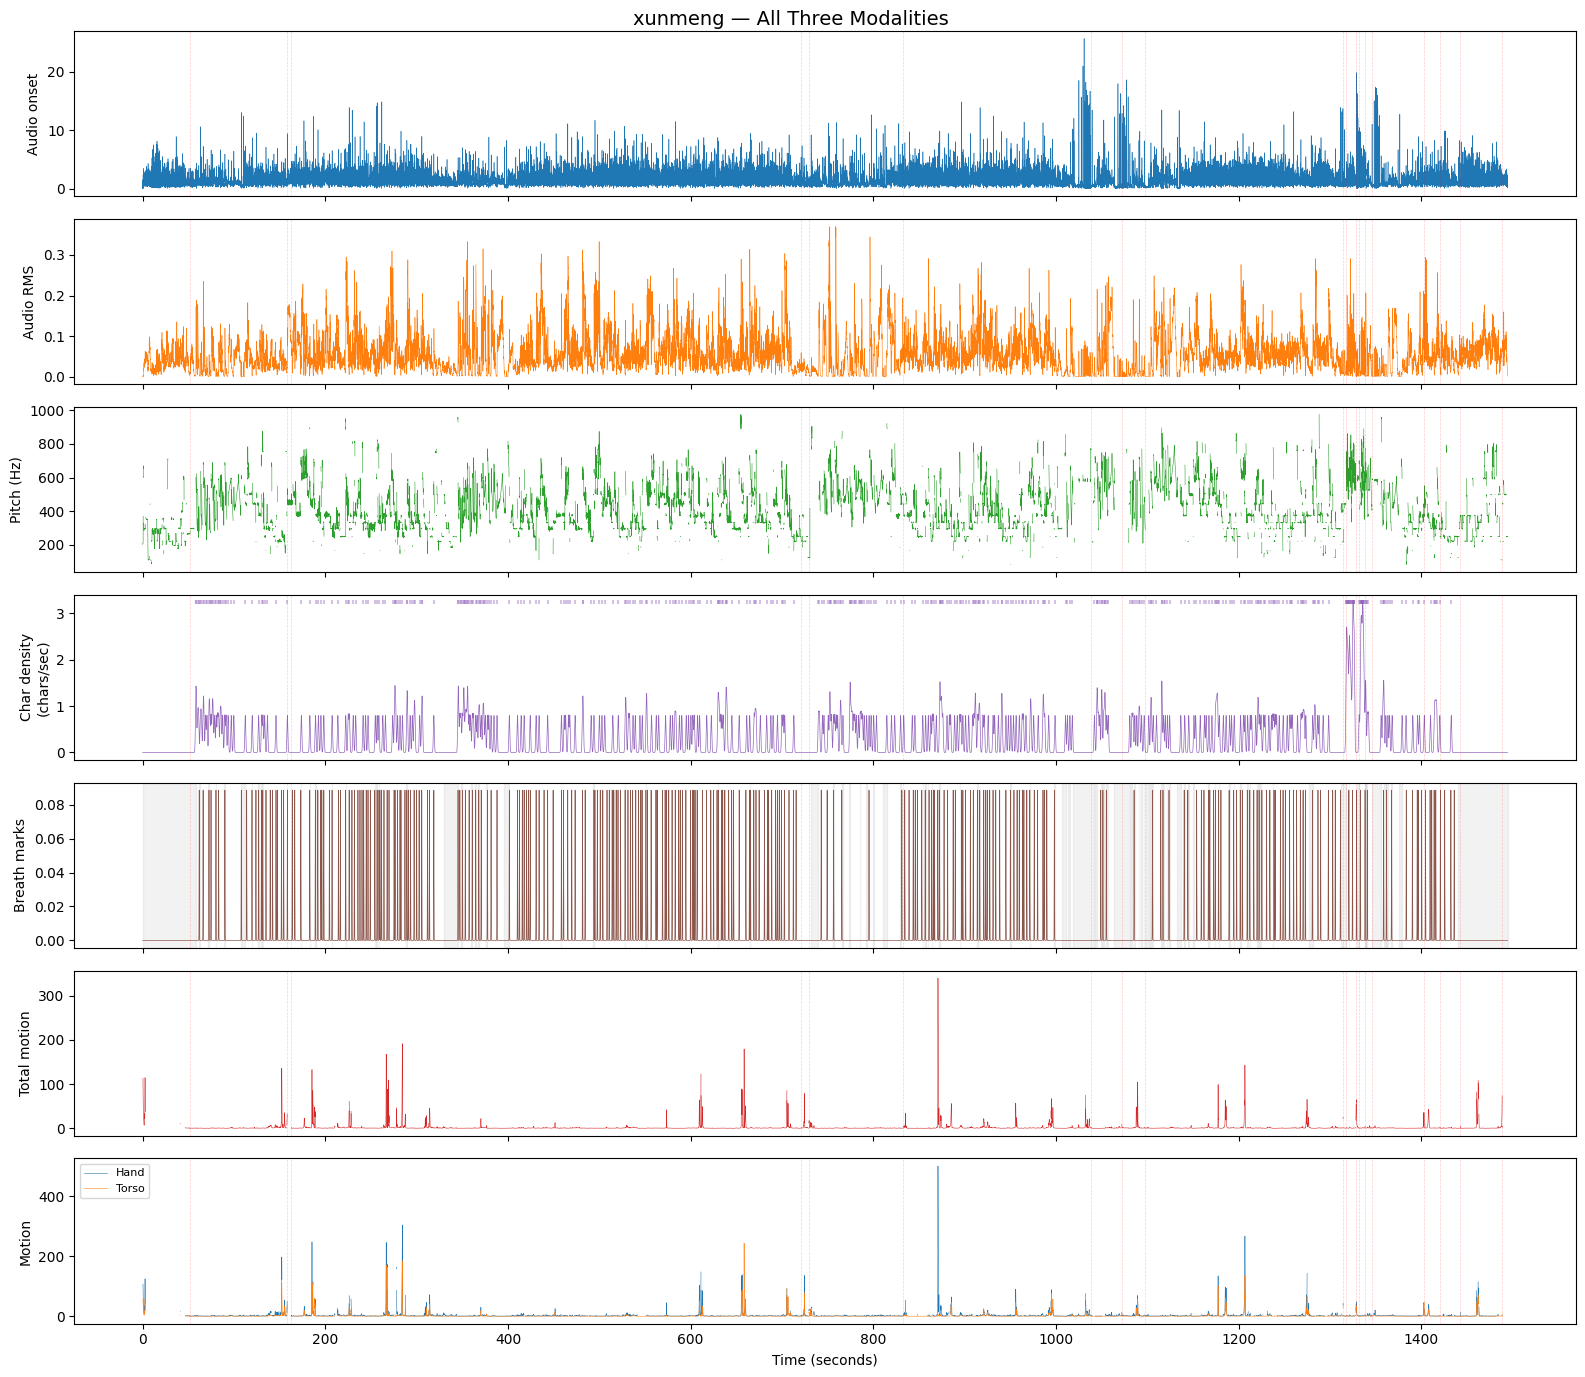

In [15]:
assert has_text, "Text modality not available — run extract_text.py and align_signals.py first"

text_onset = data["text_onset"]
text_density = data["text_density"]
text_breath = data["text_breath"]
text_silence = data["text_silence_mask"].astype(bool)
text_ioi = data["text_ioi"]
text_dur = data["text_char_duration"]

# Overview of full performance
fig, axes = plt.subplots(7, 1, figsize=(16, 14), sharex=True)

axes[0].plot(times, data["audio_onset"], lw=0.4, color="C0")
axes[0].set_ylabel("Audio onset")

axes[1].plot(times, data["audio_rms"], lw=0.4, color="C1")
axes[1].set_ylabel("Audio RMS")

axes[2].plot(times, data["audio_f0"], lw=0.4, color="C2")
axes[2].set_ylabel("Pitch (Hz)")

axes[3].plot(times, text_density, lw=0.5, color="C4")
onset_t = times[text_onset > 0]
axes[3].scatter(onset_t, np.full(len(onset_t), np.nanmax(text_density)),
                marker="|", s=8, color="C4", alpha=0.4)
axes[3].set_ylabel("Char density\n(chars/sec)")

axes[4].plot(times, text_breath, lw=0.5, color="C5")
# Shade silence regions
changes = np.diff(text_silence.astype(int))
starts = np.where(changes == 1)[0] + 1
ends = np.where(changes == -1)[0] + 1
if text_silence[0]:
    starts = np.concatenate([[0], starts])
if text_silence[-1]:
    ends = np.concatenate([ends, [len(text_silence)]])
for s, e in zip(starts, ends):
    axes[4].axvspan(times[s], times[min(e, len(times)-1)], color="grey", alpha=0.1)
axes[4].set_ylabel("Breath marks")

axes[5].plot(times, data["motion_total"], lw=0.4, color="C3")
axes[5].set_ylabel("Total motion")

axes[6].plot(times, data["motion_hand"], lw=0.4, color="C0", label="Hand")
axes[6].plot(times, data["motion_torso"], lw=0.4, color="C1", label="Torso")
axes[6].set_ylabel("Motion")
axes[6].legend(fontsize=8)

axes[-1].set_xlabel("Time (seconds)")

for ax in axes:
    for cf in shot_data["cuts"]:
        ax.axvline(cf / shot_data["video_fps"], color="red", ls="--", alpha=0.2, lw=0.5)

fig.suptitle(f"{VIDEO_ID} — All Three Modalities", fontsize=14)
plt.tight_layout()
plt.show()

## 15. Text–Audio Correlation: Character Onsets vs Audio Onsets

Do character onset impulses align with audio onset peaks? This measures how tightly
the annotated syllable boundaries match acoustic note attacks.

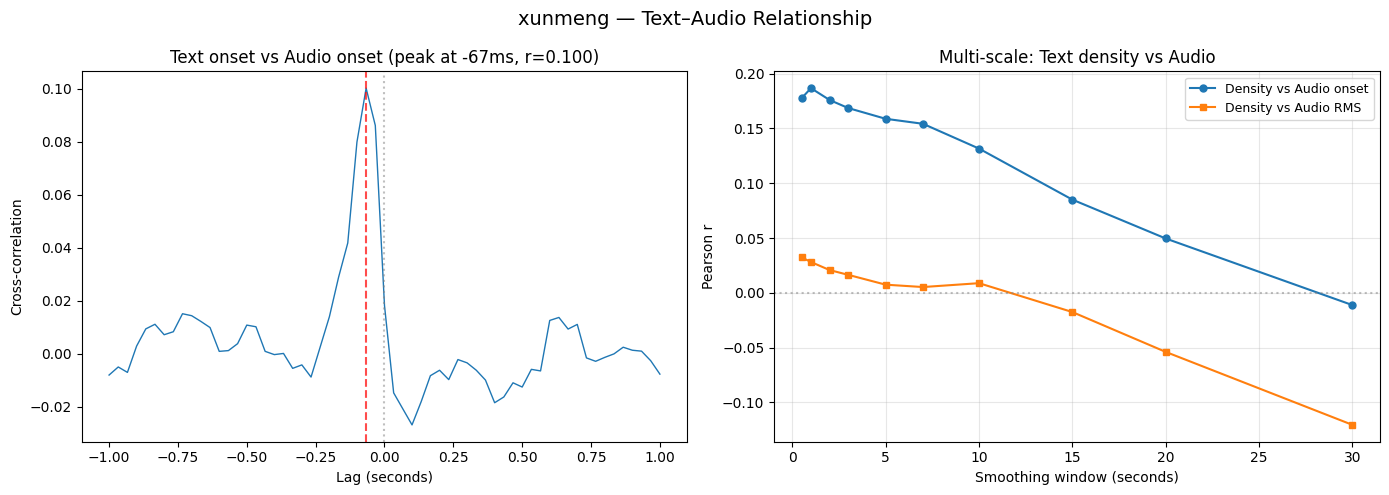

Frame-level: text onset vs audio onset: r=0.0182, p=5.23e-04
Best multi-scale density vs onset: r=0.1867 at 1s
Best multi-scale density vs RMS:   r=0.0323 at 0.5s


In [16]:
from scipy.ndimage import uniform_filter1d

# Cross-correlation: text onset vs audio onset
singing_mask = ~text_silence & ~cut_mask

v = singing_mask & ~np.isnan(data["audio_onset"])
lags, xcorr = compute_xcorr(text_onset, data["audio_onset"], v, max_lag_sec=1.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cross-correlation
axes[0].plot(lags, xcorr, lw=1)
peak_idx = np.argmax(xcorr)
peak_lag = lags[peak_idx]
axes[0].axvline(peak_lag, color="red", ls="--", alpha=0.7)
axes[0].axvline(0, color="gray", ls=":", alpha=0.5)
axes[0].set_xlabel("Lag (seconds)")
axes[0].set_ylabel("Cross-correlation")
axes[0].set_title(f"Text onset vs Audio onset (peak at {peak_lag*1000:.0f}ms, r={xcorr[peak_idx]:.3f})")

# Multi-scale correlation: text density vs audio onset
window_sizes = [0.5, 1, 2, 3, 5, 7, 10, 15, 20, 30]
corrs_density_onset = []
corrs_density_rms = []

for ws in window_sizes:
    wf = max(2, int(ws * fps))
    a_s = uniform_filter1d(data["audio_onset"], size=wf)
    d_s = uniform_filter1d(text_density, size=wf)
    r_s = uniform_filter1d(data["audio_rms"], size=wf)
    v = singing_mask & ~np.isnan(a_s)
    if v.sum() > 100:
        r1, _ = pearsonr(d_s[v], a_s[v])
        r2, _ = pearsonr(d_s[v], r_s[v])
    else:
        r1, r2 = np.nan, np.nan
    corrs_density_onset.append(r1)
    corrs_density_rms.append(r2)

axes[1].plot(window_sizes, corrs_density_onset, "o-", label="Density vs Audio onset", markersize=5)
axes[1].plot(window_sizes, corrs_density_rms, "s-", label="Density vs Audio RMS", markersize=5)
axes[1].set_xlabel("Smoothing window (seconds)")
axes[1].set_ylabel("Pearson r")
axes[1].set_title("Multi-scale: Text density vs Audio")
axes[1].legend(fontsize=9)
axes[1].axhline(0, color="gray", ls=":", alpha=0.5)
axes[1].grid(True, alpha=0.3)

fig.suptitle(f"{VIDEO_ID} — Text–Audio Relationship", fontsize=14)
plt.tight_layout()
plt.show()

# Summary
r_frame, p_frame = pearsonr(text_onset[v], data["audio_onset"][v])
print(f"Frame-level: text onset vs audio onset: r={r_frame:.4f}, p={p_frame:.2e}")
print(f"Best multi-scale density vs onset: r={max(corrs_density_onset):.4f} at {window_sizes[np.argmax(corrs_density_onset)]}s")
print(f"Best multi-scale density vs RMS:   r={max(corrs_density_rms):.4f} at {window_sizes[np.argmax(corrs_density_rms)]}s")

## 16. Text–Motion Correlation: Does Motion Track Singing Density?

The central question: does the performer's movement intensity follow the rhythmic
density of the text? Compare at multiple scales.

Frame-level correlations (singing frames only):
Text signal           Motion region           r             p         N
--------------------------------------------------------------------
Char density          Total body        -0.0388      1.76e-13     35978
Char density          Hand              -0.0304      4.77e-08     32328
Char density          Torso             -0.0345      6.17e-11     35978
Char density          Head              -0.0373      1.50e-12     35978
Onset impulse         Total body        -0.0045      3.98e-01     35978
Onset impulse         Hand              -0.0029      6.04e-01     32328
Onset impulse         Torso             -0.0026      6.17e-01     35978
Onset impulse         Head              -0.0043      4.10e-01     35978
Char duration         Total body         0.0308      5.06e-09     35978
Char duration         Hand               0.0274      8.49e-07     32328
Char duration         Torso              0.0459      2.95e-18     35978
Char duration      

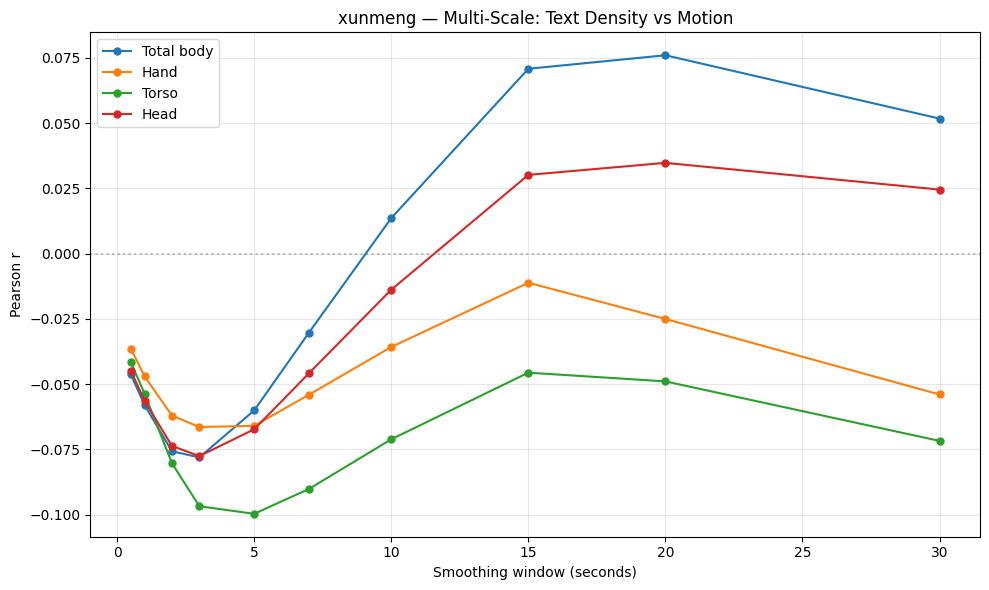

In [17]:
motion_keys = {
    "Total body": "motion_total",
    "Hand": "motion_hand",
    "Torso": "motion_torso",
    "Head": "motion_head",
}

# Frame-level correlations: text signals vs motion
print("Frame-level correlations (singing frames only):")
print(f"{'Text signal':<20s}  {'Motion region':<15s}  {'r':>8s}  {'p':>12s}  {'N':>8s}")
print("-" * 68)

text_signals = {
    "Char density": text_density,
    "Onset impulse": text_onset,
    "Char duration": text_dur,
    "IOI": text_ioi,
}

for t_name, t_sig in text_signals.items():
    for m_name, m_key in motion_keys.items():
        v = singing_mask & ~np.isnan(data[m_key]) & ~np.isnan(t_sig)
        if v.sum() > 100:
            r, p = pearsonr(t_sig[v], data[m_key][v])
            print(f"{t_name:<20s}  {m_name:<15s}  {r:>8.4f}  {p:>12.2e}  {v.sum():>8d}")

# Multi-scale: text density vs each motion region
fig, ax = plt.subplots(figsize=(10, 6))

for m_label, m_key in motion_keys.items():
    corrs = []
    for ws in window_sizes:
        wf = max(2, int(ws * fps))
        d_s = uniform_filter1d(text_density, size=wf)
        m_sig = data[m_key].copy()
        v = singing_mask & ~np.isnan(m_sig)
        m_filled = np.interp(np.arange(len(m_sig)), np.where(v)[0], m_sig[v]) if v.any() else m_sig
        m_s = uniform_filter1d(m_filled, size=wf)
        m_s[~v] = np.nan
        v2 = ~np.isnan(m_s) & singing_mask
        if v2.sum() > 100:
            r, _ = pearsonr(d_s[v2], m_s[v2])
        else:
            r = np.nan
        corrs.append(r)
    ax.plot(window_sizes, corrs, "o-", label=m_label, markersize=5)

ax.set_xlabel("Smoothing window (seconds)")
ax.set_ylabel("Pearson r")
ax.set_title(f"{VIDEO_ID} — Multi-Scale: Text Density vs Motion")
ax.legend()
ax.axhline(0, color="gray", ls=":", alpha=0.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 17. Character Onset–Triggered Motion Average

When a character onset occurs, what is the motion response? Average the motion signal
in a ±2s window around each character onset to reveal any systematic pattern.

Character onsets: 428 total, 404 with clean motion data


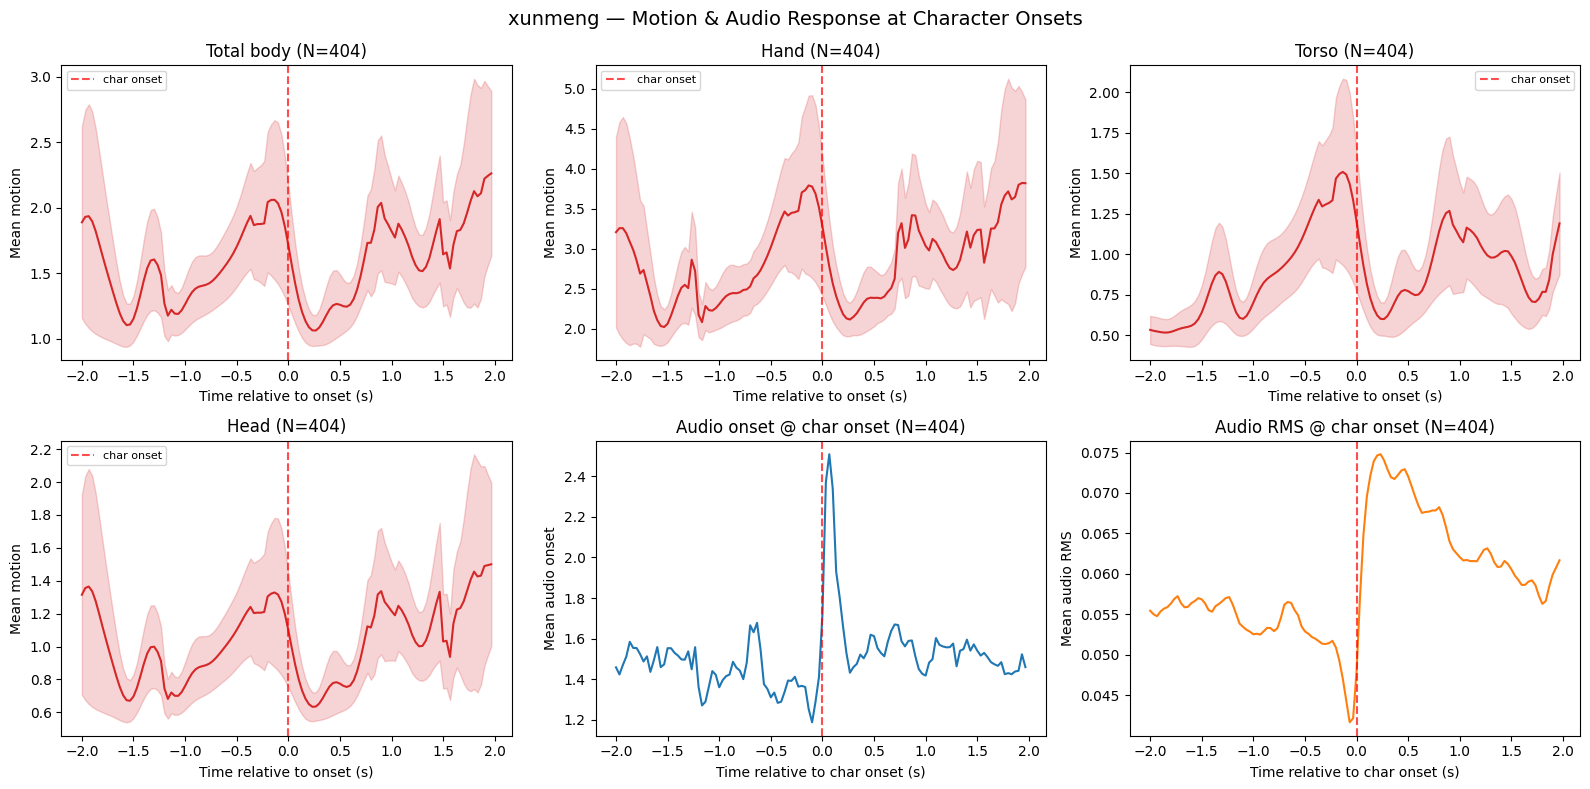

In [18]:
# Find character onset frames
char_onset_frames = np.where(text_onset > 0)[0]

window_frames = int(2 * fps)  # ±2 seconds
lag_times = np.arange(-window_frames, window_frames) / fps

# Filter valid onsets (away from edges, cuts, NaN)
valid_onsets = []
for p in char_onset_frames:
    if p < window_frames or p >= len(times) - window_frames:
        continue
    seg = slice(p - window_frames, p + window_frames)
    if cut_mask[seg].any():
        continue
    if np.isnan(data["motion_total"][seg]).mean() < 0.2:
        valid_onsets.append(p)

print(f"Character onsets: {len(char_onset_frames)} total, {len(valid_onsets)} with clean motion data")

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, (label, key) in zip(axes.flat[:4], [
    ("Total body", "motion_total"),
    ("Hand", "motion_hand"),
    ("Torso", "motion_torso"),
    ("Head", "motion_head"),
]):
    snippets = []
    for p in valid_onsets:
        seg = data[key][p - window_frames:p + window_frames]
        if len(seg) == len(lag_times):
            snippets.append(seg)
    
    if len(snippets) < 10:
        ax.set_title(f"{label} — too few events")
        continue
    
    snippets = np.array(snippets)
    mean_resp = np.nanmean(snippets, axis=0)
    sem = np.nanstd(snippets, axis=0) / np.sqrt(np.sum(~np.isnan(snippets), axis=0).clip(1))
    
    ax.plot(lag_times, mean_resp, lw=1.5, color="C3")
    ax.fill_between(lag_times, mean_resp - sem, mean_resp + sem, alpha=0.2, color="C3")
    ax.axvline(0, color="red", ls="--", alpha=0.7, label="char onset")
    ax.set_xlabel("Time relative to onset (s)")
    ax.set_ylabel("Mean motion")
    ax.set_title(f"{label} (N={len(snippets)})")
    ax.legend(fontsize=8)

# Also show audio onset response to char onset
audio_snippets = []
for p in valid_onsets:
    seg = data["audio_onset"][p - window_frames:p + window_frames]
    if len(seg) == len(lag_times):
        audio_snippets.append(seg)
audio_snippets = np.array(audio_snippets)
axes[1, 1].plot(lag_times, np.nanmean(audio_snippets, axis=0), lw=1.5, color="C0")
axes[1, 1].axvline(0, color="red", ls="--", alpha=0.7)
axes[1, 1].set_xlabel("Time relative to char onset (s)")
axes[1, 1].set_ylabel("Mean audio onset")
axes[1, 1].set_title(f"Audio onset @ char onset (N={len(audio_snippets)})")

# RMS response
rms_snippets = []
for p in valid_onsets:
    seg = data["audio_rms"][p - window_frames:p + window_frames]
    if len(seg) == len(lag_times):
        rms_snippets.append(seg)
rms_snippets = np.array(rms_snippets)
axes[1, 2].plot(lag_times, np.nanmean(rms_snippets, axis=0), lw=1.5, color="C1")
axes[1, 2].axvline(0, color="red", ls="--", alpha=0.7)
axes[1, 2].set_xlabel("Time relative to char onset (s)")
axes[1, 2].set_ylabel("Mean audio RMS")
axes[1, 2].set_title(f"Audio RMS @ char onset (N={len(rms_snippets)})")

fig.suptitle(f"{VIDEO_ID} — Motion & Audio Response at Character Onsets", fontsize=14)
plt.tight_layout()
plt.show()

## 18. Breath Mark–Triggered Motion Analysis

Breath marks indicate phrase boundaries. Does motion show systematic behavior at
breath points — pausing, transitioning, or resetting?

Breath events: 298 detected, 289 with clean motion data


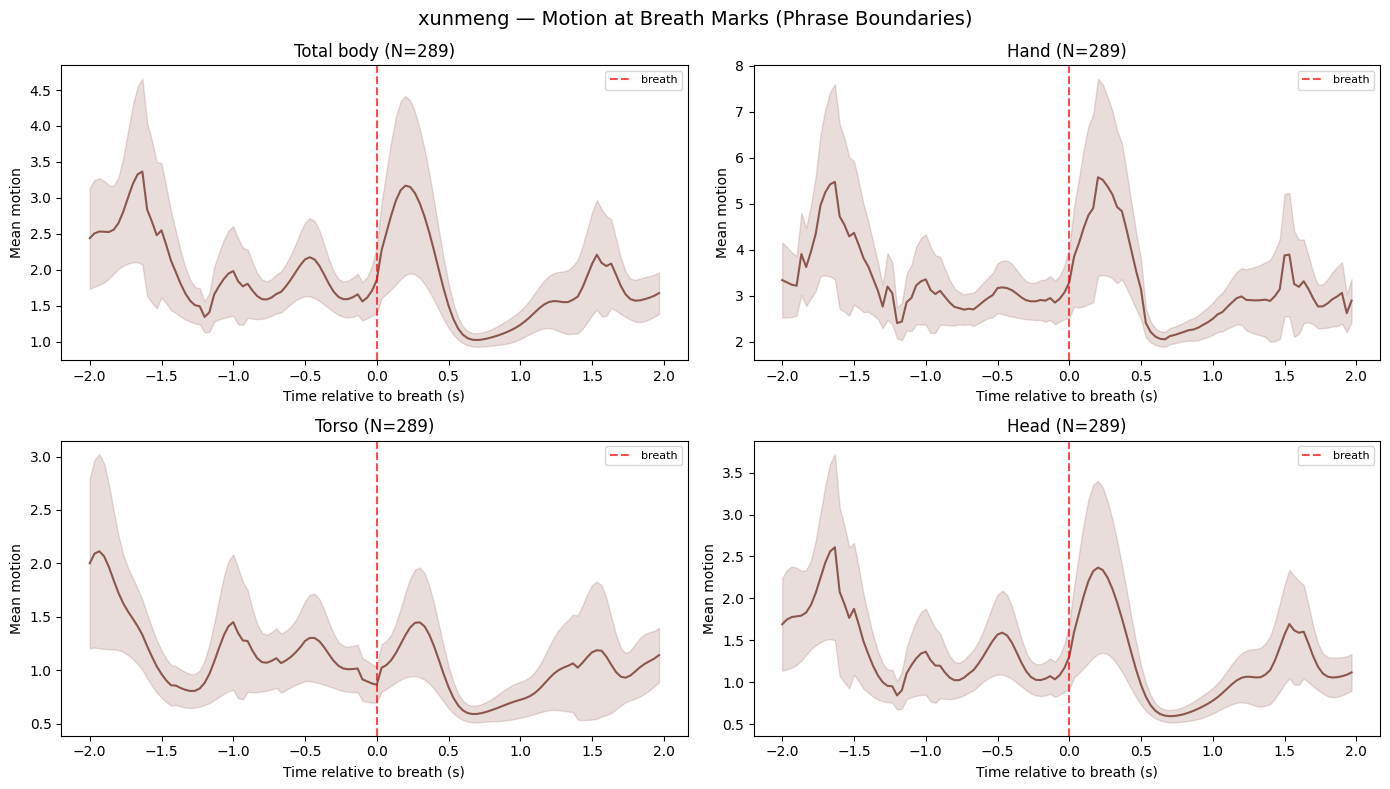

In [19]:
# Find breath mark peaks
breath_frames = np.where(text_breath > text_breath.max() * 0.5)[0]
# Cluster nearby frames into single breath events (take local maxima)
from scipy.signal import find_peaks
breath_peaks, _ = find_peaks(text_breath, height=text_breath.max() * 0.3, distance=int(1.0 * fps))

# Filter valid breaths
valid_breaths = []
for p in breath_peaks:
    if p < window_frames or p >= len(times) - window_frames:
        continue
    seg = slice(p - window_frames, p + window_frames)
    if cut_mask[seg].any():
        continue
    if np.isnan(data["motion_total"][seg]).mean() < 0.2:
        valid_breaths.append(p)

print(f"Breath events: {len(breath_peaks)} detected, {len(valid_breaths)} with clean motion data")

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (label, key) in zip(axes.flat, [
    ("Total body", "motion_total"),
    ("Hand", "motion_hand"),
    ("Torso", "motion_torso"),
    ("Head", "motion_head"),
]):
    snippets = []
    for p in valid_breaths:
        seg = data[key][p - window_frames:p + window_frames]
        if len(seg) == len(lag_times):
            snippets.append(seg)
    
    if len(snippets) < 10:
        ax.set_title(f"{label} — too few events")
        continue
    
    snippets = np.array(snippets)
    mean_resp = np.nanmean(snippets, axis=0)
    sem = np.nanstd(snippets, axis=0) / np.sqrt(np.sum(~np.isnan(snippets), axis=0).clip(1))
    
    ax.plot(lag_times, mean_resp, lw=1.5, color="C5")
    ax.fill_between(lag_times, mean_resp - sem, mean_resp + sem, alpha=0.2, color="C5")
    ax.axvline(0, color="red", ls="--", alpha=0.7, label="breath")
    ax.set_xlabel("Time relative to breath (s)")
    ax.set_ylabel("Mean motion")
    ax.set_title(f"{label} (N={len(snippets)})")
    ax.legend(fontsize=8)

fig.suptitle(f"{VIDEO_ID} — Motion at Breath Marks (Phrase Boundaries)", fontsize=14)
plt.tight_layout()
plt.show()

## 19. Windowed Three-Way Correlation

Track the pairwise correlations between all three modalities over time using
sliding windows. This reveals which passages have tight text–audio–motion coupling
and which are decoupled.

/tmp/ipykernel_2090090/116867269.py:32: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_ta, _ = pearsonr(density_env[s][v_all], onset_env[s][v_all])
/tmp/ipykernel_2090090/116867269.py:33: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_tm, _ = pearsonr(density_env[s][v_all], motion_env[s][v_all])


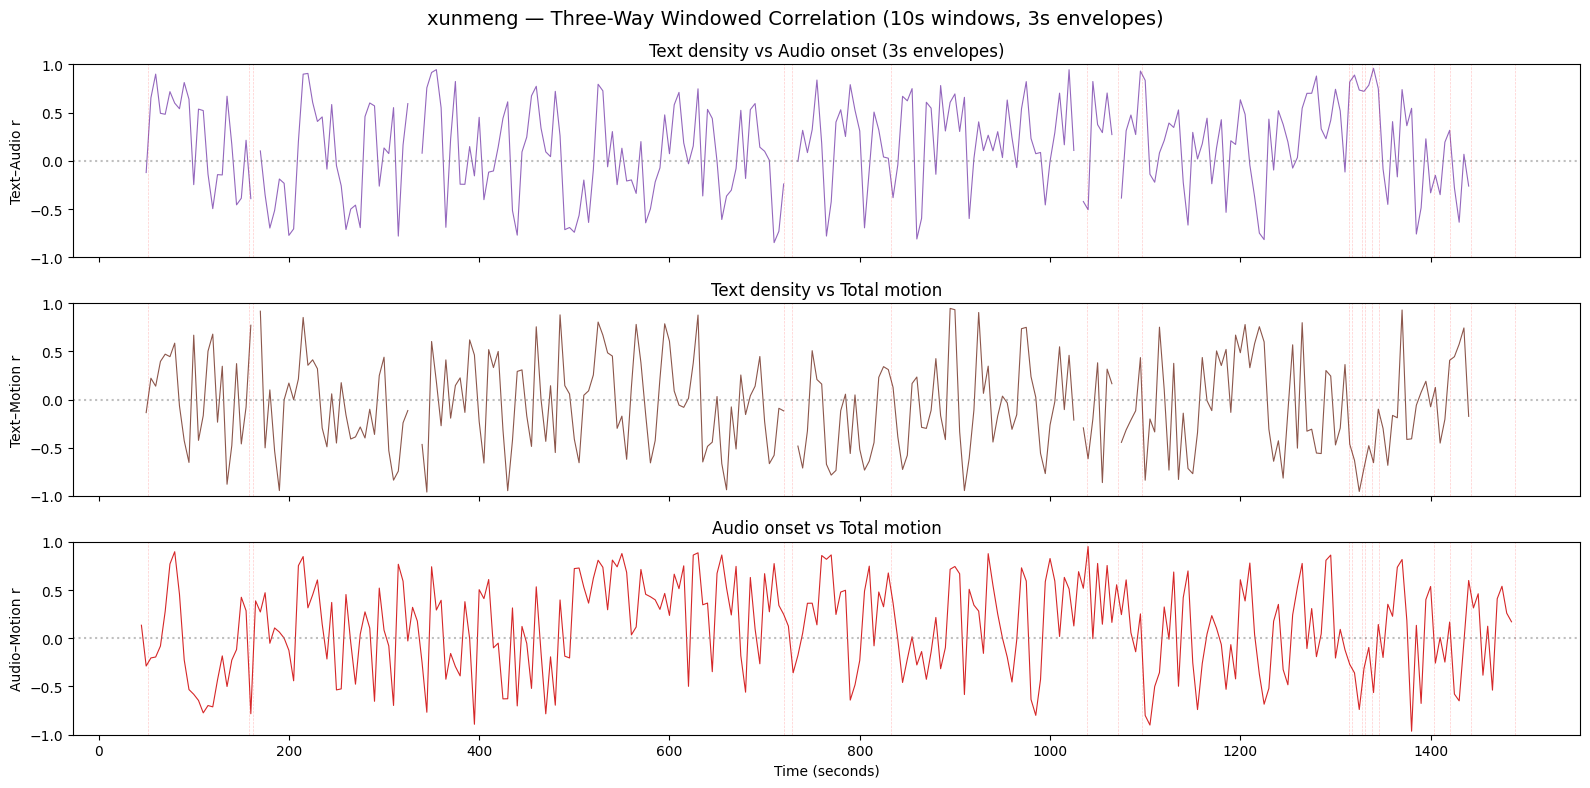


Mean windowed correlations:
  Text–Audio:  r = 0.139 ± 0.469
  Text–Motion: r = -0.055 ± 0.473
  Audio–Motion: r = 0.112 ± 0.473


In [20]:
window_sec = 10
window = int(window_sec * fps)
step = window // 2

# Smooth signals for phrase-level comparison
env_w = int(3 * fps)
density_env = uniform_filter1d(text_density, size=env_w)
onset_env = uniform_filter1d(data["audio_onset"], size=env_w)
rms_env = uniform_filter1d(data["audio_rms"], size=env_w)

mt = data["motion_total"].copy()
v = ~np.isnan(mt)
mt_filled = np.interp(np.arange(len(mt)), np.where(v)[0], mt[v]) if v.any() else mt
motion_env = uniform_filter1d(mt_filled, size=env_w)
motion_env[~v] = np.nan

w_times = []
w_text_audio = []
w_text_motion = []
w_audio_motion = []

for i in range(0, len(times) - window, step):
    s = slice(i, i + window)
    t_mid = times[i + window // 2]
    
    v_all = ~np.isnan(motion_env[s]) & ~cut_mask[s]
    if v_all.sum() < window * 0.3:
        continue
    
    w_times.append(t_mid)
    
    r_ta, _ = pearsonr(density_env[s][v_all], onset_env[s][v_all])
    r_tm, _ = pearsonr(density_env[s][v_all], motion_env[s][v_all])
    r_am, _ = pearsonr(onset_env[s][v_all], motion_env[s][v_all])
    
    w_text_audio.append(r_ta)
    w_text_motion.append(r_tm)
    w_audio_motion.append(r_am)

fig, axes = plt.subplots(3, 1, figsize=(16, 8), sharex=True)

axes[0].plot(w_times, w_text_audio, lw=0.8, color="C4")
axes[0].set_ylabel("Text–Audio r")
axes[0].axhline(0, color="gray", ls=":", alpha=0.5)
axes[0].set_title("Text density vs Audio onset (3s envelopes)")

axes[1].plot(w_times, w_text_motion, lw=0.8, color="C5")
axes[1].set_ylabel("Text–Motion r")
axes[1].axhline(0, color="gray", ls=":", alpha=0.5)
axes[1].set_title("Text density vs Total motion")

axes[2].plot(w_times, w_audio_motion, lw=0.8, color="C3")
axes[2].set_ylabel("Audio–Motion r")
axes[2].axhline(0, color="gray", ls=":", alpha=0.5)
axes[2].set_title("Audio onset vs Total motion")

for ax in axes:
    for cf in shot_data["cuts"]:
        ax.axvline(cf / shot_data["video_fps"], color="red", ls="--", alpha=0.2, lw=0.5)
    ax.set_ylim(-1, 1)

axes[-1].set_xlabel("Time (seconds)")
fig.suptitle(f"{VIDEO_ID} — Three-Way Windowed Correlation ({window_sec}s windows, 3s envelopes)", fontsize=14)
plt.tight_layout()
plt.show()

# Summary statistics
print(f"\nMean windowed correlations:")
print(f"  Text–Audio:  r = {np.nanmean(w_text_audio):.3f} ± {np.nanstd(w_text_audio):.3f}")
print(f"  Text–Motion: r = {np.nanmean(w_text_motion):.3f} ± {np.nanstd(w_text_motion):.3f}")
print(f"  Audio–Motion: r = {np.nanmean(w_audio_motion):.3f} ± {np.nanstd(w_audio_motion):.3f}")

## 20. Singing Style Comparison

Compare motion behavior during different singing styles (普通唱 vs 念白式).
Load the per-character metadata to segment by style.

Singing styles found: [np.str_('念白式'), np.str_('普通唱')]

Style          N chars  Avg dur(s)    Avg motion    Avg hand     Avg RMS
----------------------------------------------------------------------
念白式                 24        2.06        0.4879      1.1132      0.0509


/tmp/ipykernel_2090090/2487824634.py:34: RuntimeWarning: Mean of empty slice
  style_hand.append(np.nanmean(mh_seg))


普通唱                404        2.88        1.9033         nan      0.0644


/tmp/ipykernel_2090090/2487824634.py:57: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(bp_data, labels=[str(s) for s in styles], patch_artist=True)
/tmp/ipykernel_2090090/2487824634.py:57: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(bp_data, labels=[str(s) for s in styles], patch_artist=True)
/tmp/ipykernel_2090090/2487824634.py:57: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(bp_data, labels=[str(s) for s in styles], patch_artist=True)
/tmp/ipykernel_2090090/2487824634.py:65: UserWarning: Glyph 24565 (\N{CJK UNIFIED IDEOGRAPH-5FF5}) missing from font(s) DejaVu Sans.


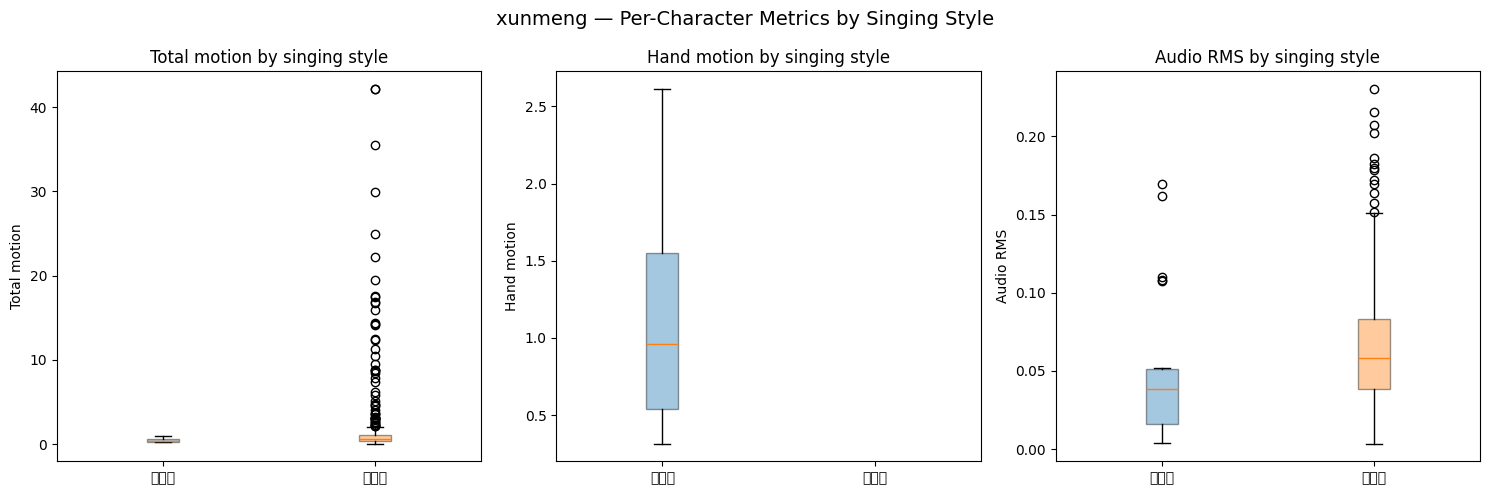


Mann-Whitney U (Total motion): 念白式 vs 普通唱: U=3318, p=0.0094

Mann-Whitney U (Hand motion): 念白式 vs 普通唱: U=nan, p=nan


In [21]:
# Load per-character data from text features
text_data = np.load(f"../data/processed/{VIDEO_ID}_text_features.npz", allow_pickle=True)
char_onsets_sec = text_data["char_onsets"]
char_offsets_sec = text_data["char_offsets"]
char_styles = text_data["char_singing_styles"]
char_durations = text_data["char_durations"]

styles = np.unique(char_styles)
print(f"Singing styles found: {list(styles)}")

# For each style, compute motion statistics during those characters
print(f"\n{'Style':<12s}  {'N chars':>8s}  {'Avg dur(s)':>10s}  {'Avg motion':>12s}  {'Avg hand':>10s}  {'Avg RMS':>10s}")
print("-" * 70)

style_data = {}
for style in styles:
    mask = char_styles == style
    style_motion = []
    style_hand = []
    style_rms_vals = []
    
    for onset, offset in zip(char_onsets_sec[mask], char_offsets_sec[mask]):
        i_start = max(0, int(round(onset * fps)))
        i_end = min(len(times), int(round(offset * fps)))
        if i_end <= i_start:
            continue
        seg = slice(i_start, i_end)
        mt_seg = data["motion_total"][seg]
        mh_seg = data["motion_hand"][seg]
        rms_seg = data["audio_rms"][seg]
        
        if not np.all(np.isnan(mt_seg)):
            style_motion.append(np.nanmean(mt_seg))
            style_hand.append(np.nanmean(mh_seg))
            style_rms_vals.append(np.nanmean(rms_seg))
    
    style_data[style] = {
        "motion": np.array(style_motion),
        "hand": np.array(style_hand),
        "rms": np.array(style_rms_vals),
        "durations": char_durations[mask],
    }
    
    n = mask.sum()
    avg_dur = np.mean(char_durations[mask])
    avg_m = np.mean(style_motion) if style_motion else 0
    avg_h = np.mean(style_hand) if style_hand else 0
    avg_r = np.mean(style_rms_vals) if style_rms_vals else 0
    print(f"{style:<12s}  {n:>8d}  {avg_dur:>10.2f}  {avg_m:>12.4f}  {avg_h:>10.4f}  {avg_r:>10.4f}")

# Box plots
if len(styles) >= 2:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    for ax, (metric, label) in zip(axes, [("motion", "Total motion"), ("hand", "Hand motion"), ("rms", "Audio RMS")]):
        bp_data = [style_data[s][metric] for s in styles]
        bp = ax.boxplot(bp_data, labels=[str(s) for s in styles], patch_artist=True)
        for patch, color in zip(bp["boxes"], ["C0", "C1", "C2", "C3"]):
            patch.set_facecolor(color)
            patch.set_alpha(0.4)
        ax.set_ylabel(label)
        ax.set_title(f"{label} by singing style")
    
    fig.suptitle(f"{VIDEO_ID} — Per-Character Metrics by Singing Style", fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Statistical test
    from scipy.stats import mannwhitneyu
    for metric, label in [("motion", "Total motion"), ("hand", "Hand motion")]:
        if len(styles) == 2:
            u, p = mannwhitneyu(style_data[styles[0]][metric], style_data[styles[1]][metric], alternative="two-sided")
            print(f"\nMann-Whitney U ({label}): {styles[0]} vs {styles[1]}: U={u:.0f}, p={p:.4f}")